In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as daatetime
import scipy.stats as st
import random
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv(r"C:\Users\ayush\Downloads\fraud detection.zip")

In [3]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [4]:
# df.copy()

In [5]:
df.drop(columns = ['nameOrig','nameDest','isFlaggedFraud'],inplace = True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   oldbalanceDest  float64
 6   newbalanceDest  float64
 7   isFraud         int64  
dtypes: float64(5), int64(2), str(1)
memory usage: 388.3 MB


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00


In [8]:
df.isnull().sum()

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

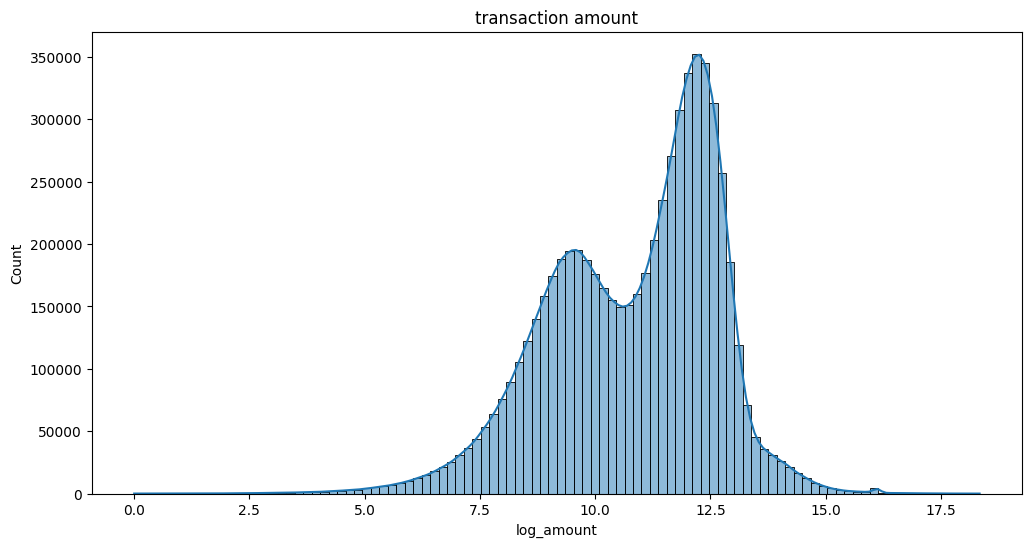

In [9]:
df['log_amount'] = np.log1p(df['amount'])
plt.figure(figsize = (12,6))
sns.histplot(df['log_amount'],bins = 100,kde = True)
plt.title('transaction amount')
plt.show()

<Axes: >

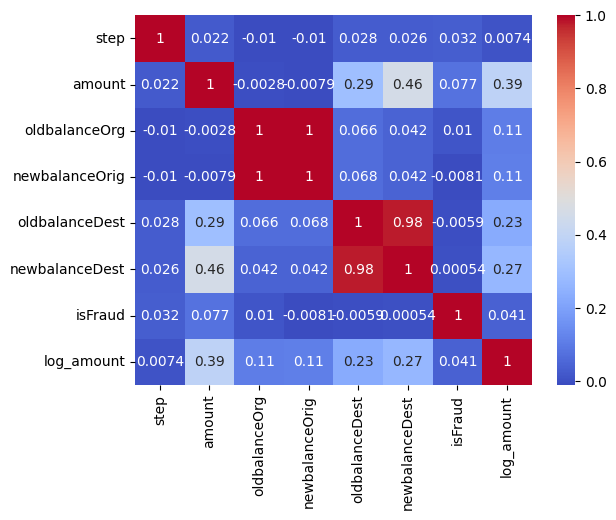

In [10]:
corr_matrix = df.corr(numeric_only= True)
sns.heatmap(corr_matrix,annot = True,cmap = 'coolwarm')
# so there is some correlated features,which created multicollinearity

In [11]:
# now now we do feature extraction
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['log_amount'] -df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] + df['log_amount'] - df['oldbalanceDest']
df['is_drained'] = (df['balance_diff_orig'] == 0).astype(int)

In [12]:
# dropping multicollinearted features and amount(becuase log_amount is better for modelling)
df.drop(columns = ['newbalanceOrig','newbalanceDest','amount'],inplace = True)

<Axes: >

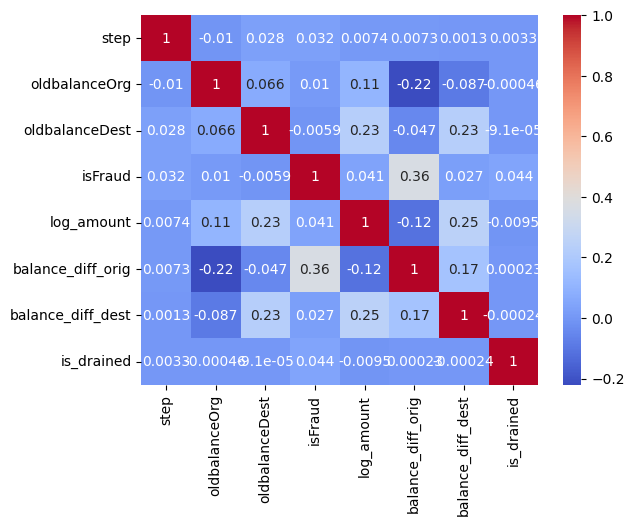

In [13]:
corr_matrix = df.corr(numeric_only= True)
sns.heatmap(corr_matrix,annot = True,cmap = 'coolwarm')
# so there is no correlated feature now

<Axes: xlabel='isFraud', ylabel='count'>

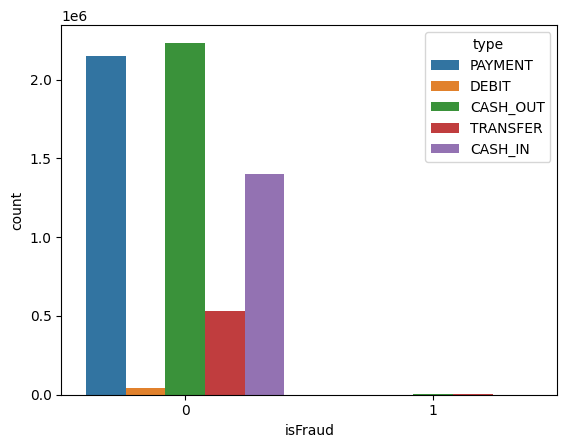

In [ ]:
sns.countplot(x =df['isFraud'],hue = df['type'],data = df)
# transfer and cash out are the biggest type for fraud

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   step               int64  
 1   type               str    
 2   oldbalanceOrg      float64
 3   oldbalanceDest     float64
 4   isFraud            int64  
 5   log_amount         float64
 6   balance_diff_orig  float64
 7   balance_diff_dest  float64
 8   is_drained         int64  
dtypes: float64(5), int64(3), str(1)
memory usage: 436.9 MB


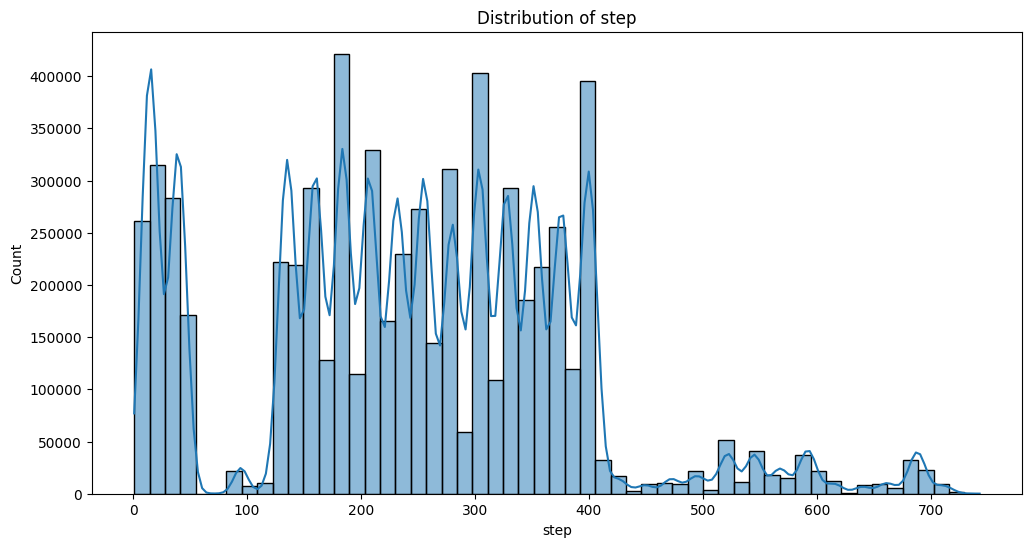

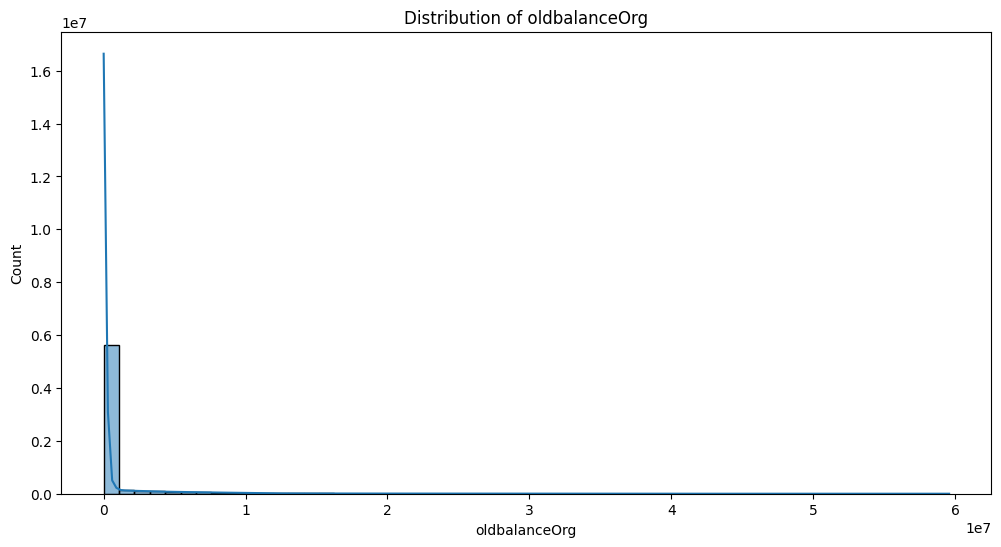

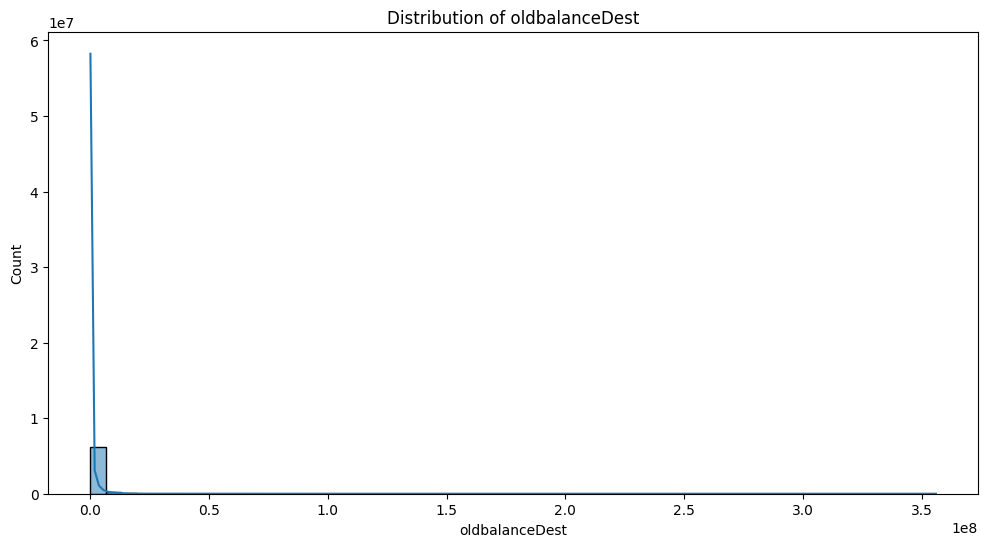

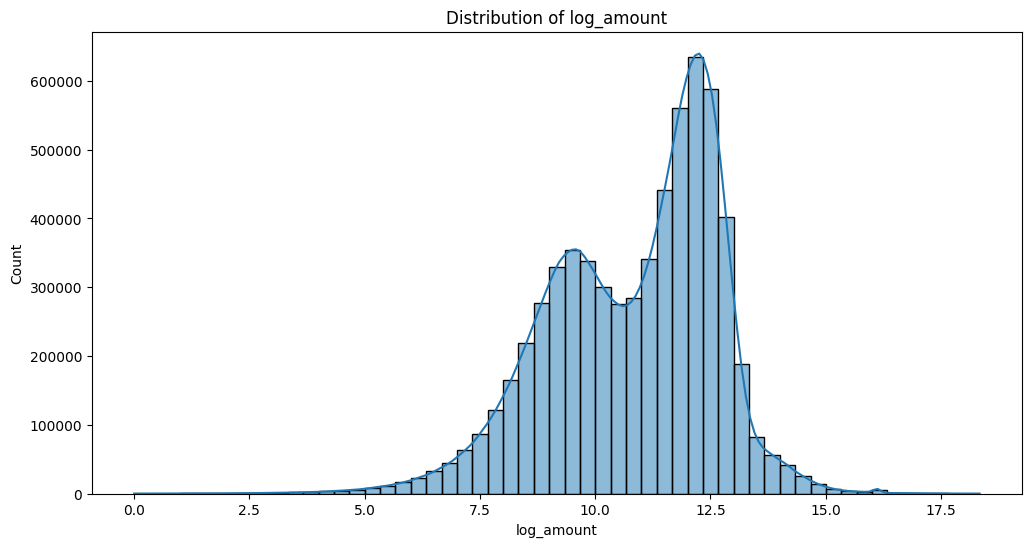

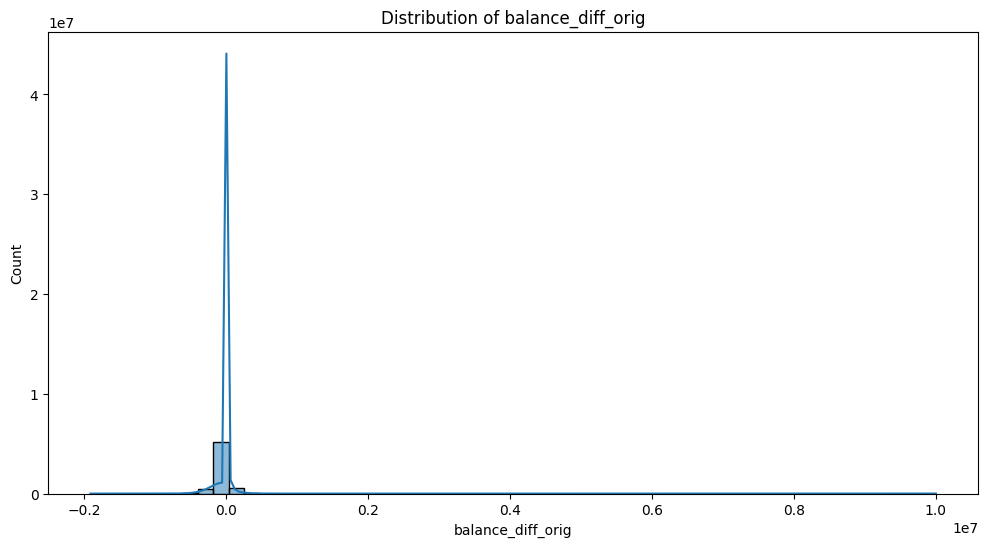

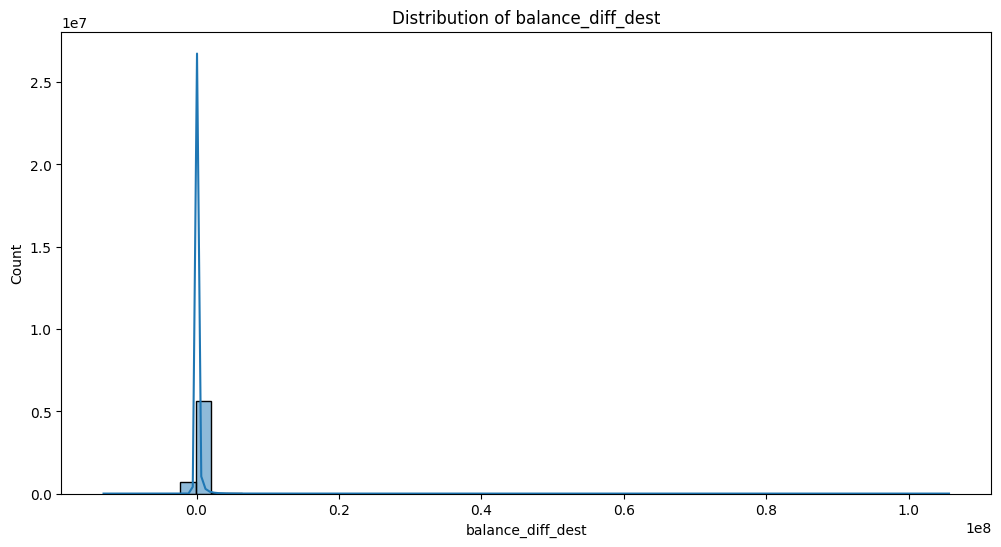

In [16]:
features = ['step','oldbalanceOrg','oldbalanceDest','log_amount','balance_diff_orig','balance_diff_dest']

for col in features:
 plt.figure(figsize = (12,6))
 sns.histplot(df[col],kde = True,bins = 55)
 plt.title(f'Distribution of {col}')
 plt.show()

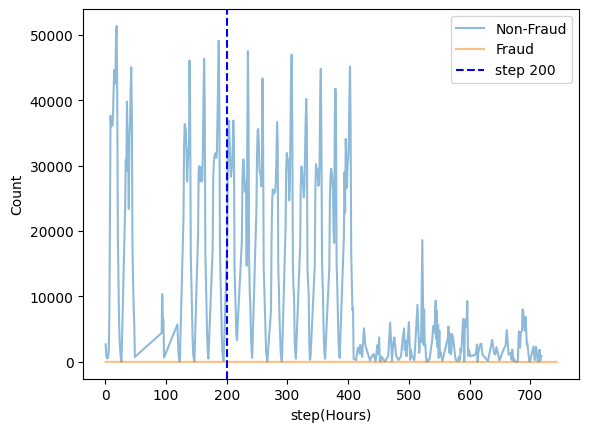

In [17]:
# more transaction happens around 200 steps
df[df['isFraud'] == 0].groupby('step').size().plot(label = 'Non-Fraud',alpha = 0.5)
df[df['isFraud'] == 1].groupby('step').size().plot(label = 'Fraud',alpha = 0.5)
plt.axvline(x = 200,color = 'blue',linestyle = '--',label = 'step 200')
plt.xlabel('step(Hours)')
plt.ylabel('Count')
plt.legend()
plt.show()

- step 200 has the highest transcation count
- transcation gradually increase upto to step 200
- this peak period could be a high risk window for fraudlent activites

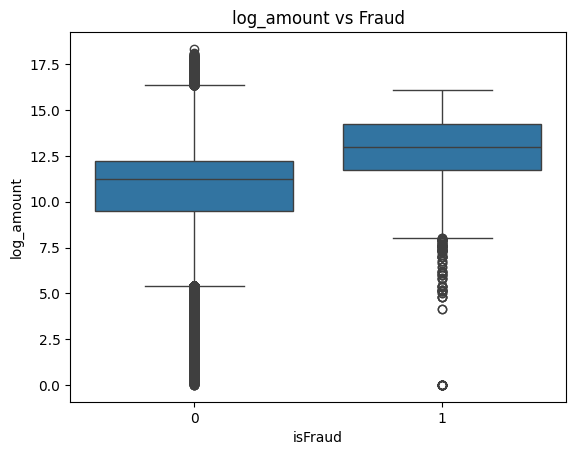

In [18]:
sns.boxplot(x = df['isFraud'],y =df['log_amount'],data = df)
plt.title('log_amount vs Fraud')
plt.show()

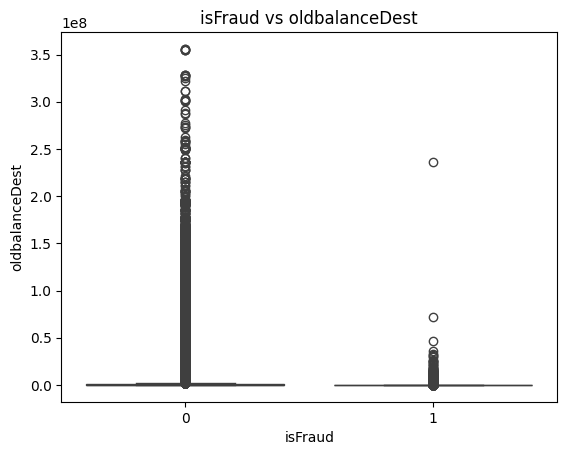

In [19]:
sns.boxplot(x = 'isFraud',y = 'oldbalanceDest',data = df)
plt.title('isFraud vs oldbalanceDest')
plt.show()

In [20]:
q3 = df['log_amount'].quantile(0.75)
IQR = df['log_amount'].quantile(0.75) - df['log_amount'].quantile(0.25)
outliers = df[df['log_amount'] > q3 + 1.5 *IQR]
print(f'total outliers:{len(outliers)}')
print(f'Fraud in Outliers:{outliers['isFraud'].sum()}')


total outliers:1786
Fraud in Outliers:0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,precision_recall_curve,precision_score,recall_score,classification_report,roc_curve,roc_auc_score,confusion_matrix,f1_score
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

In [22]:
# if df['type'].dtype == '0':
df = df[df['type'].isin(['TRANSFER','CASH_OUT'])]
df['type'] = df['type'].map({'CASH_OUT':0,'TRANSFER':1})

In [23]:
x = df.drop(columns ='isFraud')
y = df['isFraud']

In [24]:
num_col = [col for col in df.columns if df[col].dtype != 'str' and col != 'isFraud']
cat_col = [col for col in df.columns if df[col].dtype == 'str']

In [25]:
preprocessor = ColumnTransformer([
    ('scaler',StandardScaler(),num_col),
    ('encoding',OneHotEncoder(),cat_col)
])

In [27]:
df['type'].unique()

array([1, 0])

In [28]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [29]:
from imblearn.over_sampling import SMOTE

In [ ]:

x = df.drop(columns ='isFraud')
y = df['isFraud']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state= 42)
sm = SMOTE(random_state=42)
x_train_res,y_train_res = sm.fit_resample(x_train,y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: isFraud
0    2209760
1       6567
Name: count, dtype: int64
After SMOTE: isFraud
0    2209760
1    2209760
Name: count, dtype: int64


In [31]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [32]:
from xgboost import XGBClassifier
xg = Pipeline(steps=[
      ('preprocessor:',preprocessor),
      ('xgboost:',XGBClassifier(n_estimator = 500,learning_rate = 0.1,random_state = 42))

])

In [33]:
xg.fit(x_train_res,y_train_res)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor:', ...), ('xgboost:', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoding', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

accuracy_score: 0.9862276702726311
precision_score: 0.17645150827116446
recall_score: 0.991494532199271
f1_score: 0.2995869664983938
classification_report:               precision    recall  f1-score   support

           0       1.00      0.99      0.99    552436
           1       0.18      0.99      0.30      1646

    accuracy                           0.99    554082
   macro avg       0.59      0.99      0.65    554082
weighted avg       1.00      0.99      0.99    554082

roc_auc_score: 0.9888532548476533


<Axes: >

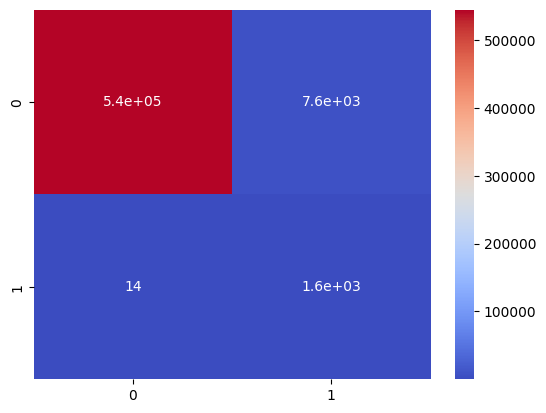

In [34]:
y_pred = xg.predict(x_test)
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('precision_score:',precision_score(y_test,y_pred))
print('recall_score:',recall_score(y_test,y_pred))
print('f1_score:',f1_score(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('roc_auc_score:',roc_auc_score(y_test,y_pred))
c = confusion_matrix(y_test,y_pred)
sns.heatmap(c,annot= True,cmap = 'coolwarm')


In [36]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Get predicted probabilities (not class labels)
y_prob = xg.predict_proba(x_test)[:, 1]

# Test different thresholds
thresholds = np.arange(0.1, 1.0, 0.05)

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"{thresh:<12.2f} {p:<12.3f} {r:<12.3f} {f1:<12.3f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.10         0.055        0.996        0.104       
0.15         0.069        0.995        0.130       
0.20         0.085        0.995        0.156       
0.25         0.098        0.995        0.178       
0.30         0.111        0.994        0.200       
0.35         0.125        0.994        0.223       
0.40         0.141        0.993        0.246       
0.45         0.157        0.991        0.272       
0.50         0.176        0.991        0.300       
0.55         0.198        0.990        0.330       
0.60         0.225        0.989        0.366       
0.65         0.255        0.986        0.405       
0.70         0.292        0.984        0.451       
0.75         0.340        0.979        0.505       
0.80         0.413        0.968        0.579       
0.85         0.534        0.945        0.682       
0.90         0.704        0.915        0.796       
0.95         0.

In [ ]:
best_thresh = 0.5
best_f1 = 0

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nBest Threshold: {best_thresh:.2f}  |  Best F1: {best_f1:.3f}")


y_final = (y_prob >= best_thresh).astype(int)
print(classification_report(y_test, y_final))


Best Threshold: 0.95  |  Best F1: 0.863
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552436
           1       0.85      0.87      0.86      1646

    accuracy                           1.00    554082
   macro avg       0.93      0.94      0.93    554082
weighted avg       1.00      1.00      1.00    554082



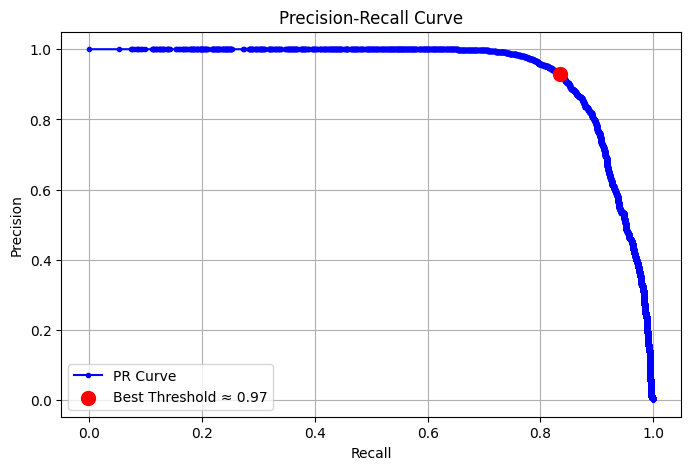

Best Threshold : 0.97
Precision      : 0.93
Recall         : 0.83


In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', color='blue', label='PR Curve')


best_idx = np.argmax(2 * (precision * recall) / (precision + recall + 1e-9))
plt.scatter(recall[best_idx], precision[best_idx], 
            color='red', s=100, zorder=5, label=f'Best Threshold ≈ {thresholds[best_idx]:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Threshold : {thresholds[best_idx]:.2f}")
print(f"Precision      : {precision[best_idx]:.2f}")
print(f"Recall         : {recall[best_idx]:.2f}")

In [39]:
df[['isFraud','log_amount','step']].corr()

,isFraud,log_amount,step
isFraud,1.000000,0.042649,0.048671
log_amount,0.042649,1.000000,0.000824
step,0.048671,0.000824,1.000000


In [40]:
df[['isFraud','balance_diff_orig','balance_diff_dest']].corr()

,isFraud,balance_diff_orig,balance_diff_dest
isFraud,1.000000,0.474628,0.018022
balance_diff_orig,0.474628,1.000000,0.067151
balance_diff_dest,0.018022,0.067151,1.000000


In [93]:
from xgboost import XGBClassifier
ratio = (y_train == 0).sum()/(y_train==1).sum()

model3 = XGBClassifier(
    
    scale_pos_weight=ratio,      
    
    # Model Complexity
    n_estimators=1000,           
    max_depth=6,                 
    learning_rate=0.05,          
    gamma=1,                     
    reg_lambda=2,                
    subsample=0.8,               
    colsample_bytree=0.8,        
    
)
model3.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [94]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report


y_prob = model3.predict_proba(x_test)[:, 1]


thresholds = np.arange(0.1, 1.0, 0.05)

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"{thresh:<12.2f} {p:<12.3f} {r:<12.3f} {f1:<12.3f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.10         0.239        0.989        0.386       
0.15         0.279        0.986        0.434       
0.20         0.309        0.984        0.470       
0.25         0.337        0.983        0.502       
0.30         0.367        0.981        0.534       
0.35         0.393        0.978        0.561       
0.40         0.417        0.975        0.584       
0.45         0.444        0.969        0.609       
0.50         0.472        0.961        0.633       
0.55         0.497        0.957        0.655       
0.60         0.531        0.956        0.683       
0.65         0.558        0.952        0.703       
0.70         0.590        0.950        0.728       
0.75         0.624        0.943        0.751       
0.80         0.670        0.938        0.782       
0.85         0.724        0.928        0.813       
0.90         0.790        0.918        0.849       
0.95         0.

accuracy_score: 0.9966882158236506
precision_score: 0.4718162839248434
recall_score: 0.9611178614823815
f1_score: 0.6329265853170634
classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00    552436
           1       0.47      0.96      0.63      1646

    accuracy                           1.00    554082
   macro avg       0.74      0.98      0.82    554082
weighted avg       1.00      1.00      1.00    554082

roc_auc_score: 0.9789560301336996


<Axes: >

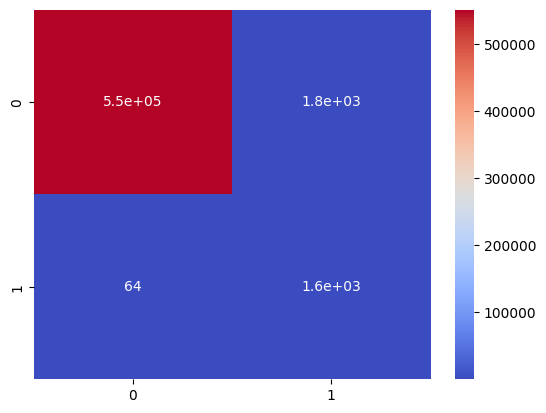

In [95]:
y_pred = model3.predict(x_test)
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('precision_score:',precision_score(y_test,y_pred))
print('recall_score:',recall_score(y_test,y_pred))
print('f1_score:',f1_score(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('roc_auc_score:',roc_auc_score(y_test,y_pred))
c = confusion_matrix(y_test,y_pred)
sns.heatmap(c,annot= True,cmap = 'coolwarm')


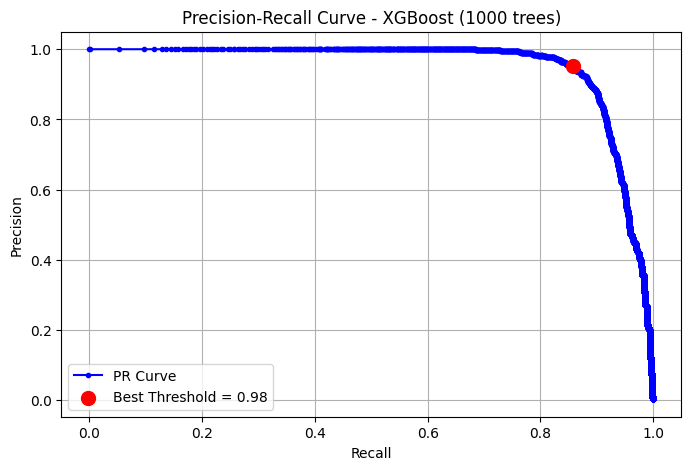

Best Threshold : 0.98
Precision      : 0.95
Recall         : 0.86


In [96]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob = model3.predict_proba(x_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', color='blue', label='PR Curve')

best_idx = np.argmax(2 * (precision * recall) / (precision + recall + 1e-9))
plt.scatter(recall[best_idx], precision[best_idx],
            color='red', s=100, zorder=5,
            label=f'Best Threshold = {thresholds[best_idx]:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost (1000 trees)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Threshold : {thresholds[best_idx]:.2f}")
print(f"Precision      : {precision[best_idx]:.2f}")
print(f"Recall         : {recall[best_idx]:.2f}")

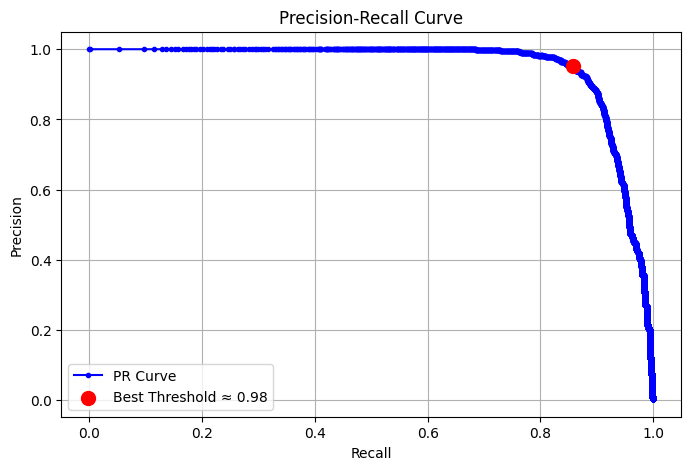

Best Threshold : 0.98
Precision      : 0.95
Recall         : 0.86


In [97]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
y_prob = model3.predict_proba(x_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', color='blue', label='PR Curve')


best_idx = np.argmax(2 * (precision * recall) / (precision + recall + 1e-9))
plt.scatter(recall[best_idx], precision[best_idx], 
            color='red', s=100, zorder=5, label=f'Best Threshold ≈ {thresholds[best_idx]:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Threshold : {thresholds[best_idx]:.2f}")
print(f"Precision      : {precision[best_idx]:.2f}")
print(f"Recall         : {recall[best_idx]:.2f}")

In [98]:

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score


y_probs = model3.predict_proba(x_test)[:, 1]

results = []

for t in np.arange(0.1, 0.96, 0.01):
    y_pred = (y_probs >= t).astype(int)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    

    if p >= 0.85 and r >= 0.85:
        results.append({'Threshold': round(t, 2), 'Precision': round(p, 4), 'Recall': round(r, 4)})


threshold_df = pd.DataFrame(results)

if not threshold_df.empty:
    print("🎯 Found the 90/90 Sweet Spot(s):")
    print(threshold_df.to_string(index=False))
    
    
    threshold_df['diff'] = abs(threshold_df['Precision'] - threshold_df['Recall'])
    best = threshold_df.sort_values('diff').iloc[0]
    print(f"\nBEST BALANCE: Threshold {best['Threshold']} yields {best['Precision']*100:.1f}% Precision and {best['Recall']*100:.1f}% Recall")
else:
    print(" No 90/90 results found. Your model needs better features (ErrorBalance) or a higher scale_pos_weight.")

    


🎯 Found the 90/90 Sweet Spot(s):
 Threshold  Precision  Recall
      0.94     0.8547  0.9040
      0.95     0.8730  0.9022

BEST BALANCE: Threshold 0.95 yields 87.3% Precision and 90.2% Recall


USING CALIBRATEDCLASSIFIERCV

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

x_cal, x_val, y_cal, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

model3.fit(x_cal, y_cal)

calibrated_model = CalibratedClassifierCV(
    estimator=model3,
    method='isotonic',
    cv=5
)
calibrated_model.fit(x_val, y_val)  
y_pred = calibrated_model.predict(x_test)
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('precision_score:',precision_score(y_test,y_pred))
print('recall_score:',recall_score(y_test,y_pred))
print('f1_score:',f1_score(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('roc_auc_score:',roc_auc_score(y_test,y_pred))
c = confusion_matrix(y_test,y_pred)
sns.heatmap(c,annot= True,cmap = 'coolwarm')



[0.28663001 0.32586058 0.32586058 0.32586058 0.32586058]


In [48]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1:", f1[best_idx])

Best Threshold: 0.9821061
Best F1: 0.9024624239987481


In [53]:
y_pred = (y_prob >= 0.97).astype(int)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[552306    130]
 [   193   1453]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552436
           1       0.92      0.88      0.90      1646

    accuracy                           1.00    554082
   macro avg       0.96      0.94      0.95    554082
weighted avg       1.00      1.00      1.00    554082



threshold 0.29 was chosen as it balances performances effectively,achieving 0.89 precision and 0.90 recall,reducing false positive while maintaing high fraud detection

In [54]:
rf = RandomForestClassifier(n_estimators= 100,max_depth= None,random_state=42)
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)

accuracy_score: 0.9992997426373713
precision_score: 0.99140625
recall_score: 0.7709599027946537
f1_score: 0.8673957621326043
classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00    552436
           1       0.99      0.77      0.87      1646

    accuracy                           1.00    554082
   macro avg       1.00      0.89      0.93    554082
weighted avg       1.00      1.00      1.00    554082

roc_auc_score: 0.8854699954929325


<Axes: >

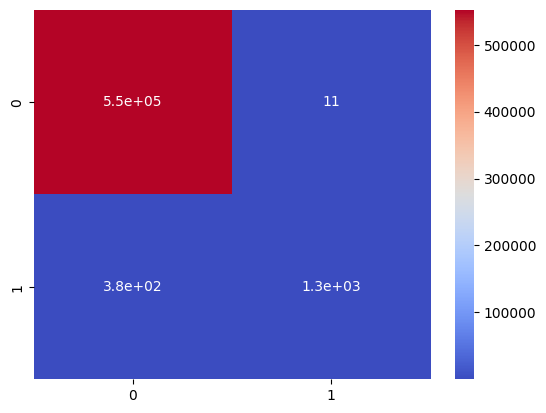

In [55]:
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('precision_score:',precision_score(y_test,y_pred))
print('recall_score:',recall_score(y_test,y_pred))
print('f1_score:',f1_score(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('roc_auc_score:',roc_auc_score(y_test,y_pred))
c = confusion_matrix(y_test,y_pred)
sns.heatmap(c,annot= True,cmap = 'coolwarm')


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Get predicted probabilities (not class labels)
y_prob = rf.predict_proba(x_test)[:, 1]

# Test different thresholds
thresholds = np.arange(0.1, 1.0, 0.05)

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"{thresh:<12.2f} {p:<12.3f} {r:<12.3f} {f1:<12.3f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.10         0.693        0.902        0.784       
0.15         0.825        0.874        0.848       
0.20         0.888        0.858        0.873       
0.25         0.930        0.836        0.881       
0.30         0.951        0.820        0.881       
0.35         0.966        0.803        0.877       
0.40         0.980        0.790        0.875       
0.45         0.986        0.777        0.869       
0.50         0.991        0.771        0.867       
0.55         0.994        0.759        0.861       
0.60         0.997        0.750        0.856       
0.65         0.997        0.744        0.852       
0.70         0.998        0.737        0.848       
0.75         0.998        0.728        0.842       
0.80         0.998        0.719        0.836       
0.85         0.998        0.707        0.828       
0.90         1.000        0.690        0.817       
0.95         1.

In [58]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)
lg.fit(x_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

accuracy_score: 0.9394512003638451
precision_score: 0.04250437376315714
recall_score: 0.9003645200486027
f1_score: 0.08117656725002054
classification_report:               precision    recall  f1-score   support

           0       1.00      0.94      0.97    552436
           1       0.04      0.90      0.08      1646

    accuracy                           0.94    554082
   macro avg       0.52      0.92      0.52    554082
weighted avg       1.00      0.94      0.97    554082

roc_auc_score: 0.9199660901874334


<Axes: >

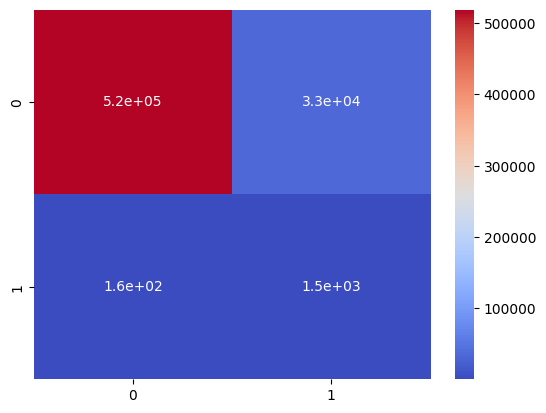

In [59]:
y_pred = lg.predict(x_test)
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('precision_score:',precision_score(y_test,y_pred))
print('recall_score:',recall_score(y_test,y_pred))
print('f1_score:',f1_score(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
print('roc_auc_score:',roc_auc_score(y_test,y_pred))
c = confusion_matrix(y_test,y_pred)
sns.heatmap(c,annot= True,cmap = 'coolwarm')


In [60]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Get predicted probabilities (not class labels)
y_prob = lg.predict_proba(x_test)[:, 1]

# Test different thresholds
thresholds = np.arange(0.1, 1.0, 0.05)

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f"{thresh:<12.2f} {p:<12.3f} {r:<12.3f} {f1:<12.3f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.10         0.008        0.994        0.017       
0.15         0.011        0.992        0.021       
0.20         0.013        0.982        0.026       
0.25         0.016        0.970        0.032       
0.30         0.020        0.956        0.038       
0.35         0.024        0.947        0.047       
0.40         0.029        0.931        0.056       
0.45         0.035        0.915        0.068       
0.50         0.043        0.900        0.081       
0.55         0.050        0.881        0.094       
0.60         0.058        0.865        0.109       
0.65         0.068        0.841        0.126       
0.70         0.080        0.820        0.146       
0.75         0.094        0.791        0.169       
0.80         0.114        0.767        0.198       
0.85         0.140        0.738        0.236       
0.90         0.184        0.711        0.292       
0.95         0.

In [99]:
import joblib
model_package = {
    'model': model3,
    'preprocessor': preprocessor,
    'threshold': 0.95
}
joblib.dump(model_package,'fraud_detection_model.pkl',compress=9)
print('saved!')

saved!
